In [1]:
from __future__ import annotations
import warnings
import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from scipy.special import gammaln

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")
np.set_printoptions(suppress=True, linewidth=140)

try:
    import duckdb
    HAS_DUCKDB = True
except Exception:
    HAS_DUCKDB = False

try:
    import pyarrow  # noqa: F401
    HAS_PYARROW = True
except Exception:
    HAS_PYARROW = False

try:
    import sklearn  # noqa: F401
    HAS_SKLEARN = True
except Exception:
    HAS_SKLEARN = False


---

# Session 1 Data overview and scope

In [2]:
# SESSION 1.1 SHARED CONTROL PANEL

DATA_PATH = Path("script/data/parquet/full.parquet")

# Amount-basis target controls. Predict actual claim amount with the same GAM predictors.
MODEL_ACTUAL_COL = "Death_Claim_Amount"
MODEL_EXPECTED_COL = "ExpDth_VBT2015_Amt"
MODEL_EXPOSURE_COL = "Amount_Exposed"
MODEL_PREDICTED_COL = "Predicted_Death_Amount"
MODEL_TARGET_LABEL = "Death Amount"
MODEL_RATE_DENOMINATOR_LABEL = "amount exposed"
MODEL_ACTUAL_SUMMARY_COL = "Actual_Death_Amount"
MODEL_EXPECTED_SUMMARY_COL = "Expected_VBT_Amount"
MODEL_PREDICTED_SUMMARY_COL = "Predicted_Death_Amount"


# Core scope filters
OBSERVATION_YEARS = None          # Example: [2018, 2019]; use None to keep all years
ISSUE_AGE_MIN = 0
ISSUE_AGE_MAX = 17
ATTAINED_AGE_MIN = 1
ATTAINED_AGE_MAX = 67
DURATION_MIN = 1
DURATION_CAP = 119

AGE_IND_KEEP = None               # Example: ["0"] or ["1"]; None keeps all age bases
SEX_KEEP = None                   # Example: ["M"] or ["F"]; None keeps all sexes
SMOKER_STATUS_KEEP = ["U"]        # Example: ["U"]; set to None to keep all
INSURANCE_PLAN_DROP = ["Other"]   # Set to [] to keep "Other"

EXCLUDE_POST_LEVEL_TERM = True
POST_LEVEL_TERM_EXCLUDE_VALUES = ["PLT"]


# 1M face-amount cap option
CAP_FACE_AT_1M = True
FACE_CAP_VALUE = 1_000_000
FACE_CAP_SOURCE_BANDS = [
    "08: 1,000,000 - 2,499,999",
    "09: 2,500,000 - 4,999,999",
    "10: 5,000,000 - 9,999,999",
    "11: 10,000,000+",
]
FACE_CAP_TARGET_BAND = "08: 1,000,000+"


# Age-basis helper columns used for testing / modeling
ISSUE_AGE_MOD_COL = "Issue_Age_mod"
ATTAINED_AGE_MOD_COL = "Attained_Age_mod"
ISSUE_AGE_MOD_MAX = ISSUE_AGE_MAX + 0.5
ATTAINED_AGE_MOD_MAX = ATTAINED_AGE_MAX + 0.5

# Credibility floor shared by the GAM knot search and validation tables.
MIN_EXPECTED_FOR_REVIEW = 3.0

In [3]:
# SESSION 1.2 OPTIONAL CONTROL PANEL

# Optional for summary work only.
COLLAPSE_DURATION_26_PLUS = False
# Optional maturity-normalized exposure scaling for later issue years for descriptive work.
APPLY_ISSUE_YEAR_EXPOSURE_SCALING = True
ISSUE_YEAR_EXPOSURE_TARGET_YEARS = 7
ISSUE_YEAR_EXPOSURE_FULL_CREDIT_START = 2013
ISSUE_YEAR_EXPOSURE_SCALE_START = 2014
ISSUE_YEAR_EXPOSURE_SCALE_END = 2019


In [4]:
# SESSION 1.3 NUMERIC AND CATEGORICAL COLUMNS

NUMERIC_COLS = [
    "Observation_Year", "Issue_Age", ISSUE_AGE_MOD_COL, "Duration", "Issue_Year", "Attained_Age", ATTAINED_AGE_MOD_COL,
    "Amount_Exposed", "Policies_Exposed", "Death_Claim_Amount", "Death_Count",
    "ExpDth_VBT2015_Cnt", "ExpDth_VBT2015_Amt"
]

RAW_CATEGORICAL_COLS = [
    "Age_Ind", "Sex", "Smoker_Status", "Insurance_Plan", "Face_Amount_Band",
    "SOA_Antp_Lvl_TP", "SOA_Guar_Lvl_TP", "SOA_Post_Lvl_Ind", "Slct_Ult_Ind",
    "Preferred_Indicator", "Number_of_Pfd_Classes", "Preferred_Class"
]

DERIVED_CATEGORICAL_COLS = [
    "Insurance_Plan_Group",
    "Face_Band_Group",
    "Issue_Age_Band",
    "Attained_Age_Band",
    "Duration_Band",
]

CATEGORICAL_COLS = RAW_CATEGORICAL_COLS + DERIVED_CATEGORICAL_COLS
BASE_COLUMNS = [
    "Observation_Year",
    "Issue_Age",
    "Duration",
    "Issue_Year",
    "Attained_Age",
    "Amount_Exposed",
    "Policies_Exposed",
    "Death_Claim_Amount",
    "Death_Count",
    "ExpDth_VBT2015_Cnt",
    "ExpDth_VBT2015_Amt",
] + RAW_CATEGORICAL_COLS


In [5]:
# SESSION 1.4 GROUPING CONTROLS

PLAN_GROUP_MAP = {
    "Perm": "Perm",
    "Term": "Term",
    "UL": "Perm",
    "ULSG": "Perm",
    "VL": "Perm",
    "VLSG": "Perm",
    "Other": "Other/Unknown",
    "Missing": "Missing",
}

FACE_BAND_GROUP_MAP = {
    "01: 0 - 9,999": "01-04: <100k",
    "02: 10,000 - 24,999": "01-04: <100k",
    "03: 25,000 - 49,999": "01-04: <100k",
    "04: 50,000 - 99,999": "01-04: <100k",
    "05: 100,000 - 249,999": "05-011: >100k",
    "06: 250,000 - 499,999": "05-011: >100k",
    "07: 500,000 - 999,999": "05-011: >100k",
    "08: 1,000,000 - 2,499,999": "05-011: >100k",
    "08: 1,000,000+": "05-011: >100k",
    "09: 2,500,000 - 4,999,999": "05-011: >100k",
    "10: 5,000,000 - 9,999,999": "05-011: >100k",
    "11: 10,000,000+": "05-011: >100k",
    "Missing": "Missing",
}


In [6]:
# SESSION 1.5 HELPER FUNCTIONS

# SESSION 1.5.1 DATA READ HELPERS
# Reads selected columns from the parquet source.
def read_parquet_data(path: Path, columns: list[str] | None = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Parquet file not found: {path}")
    if HAS_DUCKDB:
        cols_sql = "*" if columns is None else ", ".join([f'"{c}"' for c in columns])
        query = f"SELECT {cols_sql} FROM read_parquet('{path.as_posix()}')"
        return duckdb.sql(query).df()
    return pd.read_parquet(path, columns=columns)


# SESSION 1.5.2 FORMAT, MATH, AND METRIC HELPERS
# Forces matplotlib axes to show regular decimal labels instead of scientific notation.
def force_plain_axis(ax, axis: str = "both"):
    formatter = mtick.ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)

# Divides scalars or arrays while returning NaN instead of inf when the denominator is effectively zero.
def safe_divide(numerator, denominator):
    numerator = np.asarray(numerator, dtype=float)
    denominator = np.asarray(denominator, dtype=float)
    out = np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=float),
        where=np.abs(denominator) > 1e-12,
    )
    if np.ndim(out) == 0:
        return float(out)
    if out.size == 1:
        return float(np.ravel(out)[0])
    return out

# Computes Poisson deviance with predictions clipped above zero.
def safe_poisson_deviance(y_true, y_pred) -> float:
    y = np.asarray(y_true, dtype=float)
    mu = np.clip(np.asarray(y_pred, dtype=float), 1e-12, None)
    term = np.where(y == 0, 0.0, y * np.log(np.clip(y, 1e-12, None) / mu))
    return float(2.0 * np.sum(term - (y - mu)))

# Computes expected-weighted absolute error between actual A/E and predicted A/P.
def weighted_ae_error(actual, predicted, expected) -> float:
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    expected = np.asarray(expected, dtype=float)

    actual_ae = actual / np.clip(expected, 1e-12, None)
    pred_ae = predicted / np.clip(expected, 1e-12, None)
    return float(np.average(np.abs(actual_ae - pred_ae), weights=np.clip(expected, 1e-12, None)))


# SESSION 1.5.3 DATA SCOPE AND FEATURE ENGINEERING HELPERS
# Standardizes numeric and categorical columns into consistent data types.
def standardize_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in NUMERIC_COLS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    for col in CATEGORICAL_COLS:
        if col in out.columns:
            out[col] = out[col].astype("string").fillna("Missing")
    return out

# Creates Issue_Age_mod and Attained_Age_mod so ALB records use raw age + 0.5 and ANB records use raw age.
def derive_age_basis_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    age_ind = out["Age_Ind"].astype("string").fillna("Missing")
    out[ISSUE_AGE_MOD_COL] = pd.to_numeric(out["Issue_Age"], errors="coerce")
    out[ATTAINED_AGE_MOD_COL] = pd.to_numeric(out["Attained_Age"], errors="coerce")

    alb_mask = age_ind == "1"   # ALB
    anb_mask = age_ind == "0"   # ANB
    out.loc[alb_mask, ISSUE_AGE_MOD_COL] = out.loc[alb_mask, "Issue_Age"] + 0.5
    out.loc[alb_mask, ATTAINED_AGE_MOD_COL] = out.loc[alb_mask, "Attained_Age"] + 0.5
    out.loc[anb_mask, ISSUE_AGE_MOD_COL] = out.loc[anb_mask, "Issue_Age"]
    out.loc[anb_mask, ATTAINED_AGE_MOD_COL] = out.loc[anb_mask, "Attained_Age"]
    return out

# Optionally scales exposure for later issue years.
def apply_issue_year_exposure_scaling(df: pd.DataFrame) -> pd.DataFrame:
    if not APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        return df.copy()
    out = df.copy()
    issue_year = pd.to_numeric(out["Issue_Year"], errors="coerce")
    eligible = issue_year.between(ISSUE_YEAR_EXPOSURE_SCALE_START, ISSUE_YEAR_EXPOSURE_SCALE_END, inclusive="both")

    observed_years = ISSUE_YEAR_EXPOSURE_SCALE_END - issue_year + 1
    scale = np.where(
        eligible,
        ISSUE_YEAR_EXPOSURE_TARGET_YEARS / np.clip(observed_years, 1, None),
        1.0,
    )
    out["Policies_Exposed"] = pd.to_numeric(out["Policies_Exposed"], errors="coerce") * scale
    out["Amount_Exposed"] = pd.to_numeric(out["Amount_Exposed"], errors="coerce") * scale
    return out

# Caps selected face amount bands at 1M and adjusts amount-based actual, exposed, and expected values.
def apply_face_amount_cap_1m(df: pd.DataFrame) -> pd.DataFrame:
    if not CAP_FACE_AT_1M:
        return df.copy()
    out = df.copy()
    mask = out["Face_Amount_Band"].isin(FACE_CAP_SOURCE_BANDS)

    out.loc[mask, "Face_Amount_Band"] = FACE_CAP_TARGET_BAND
    out.loc[mask, "Death_Claim_Amount"] = FACE_CAP_VALUE * out.loc[mask, "Death_Count"]
    out.loc[mask, "Amount_Exposed"] = FACE_CAP_VALUE * out.loc[mask, "Policies_Exposed"]
    out.loc[mask, "ExpDth_VBT2015_Amt"] = FACE_CAP_VALUE * out.loc[mask, "ExpDth_VBT2015_Cnt"]
    return out

# Adds grouped plan and face-band variables.
def add_grouped_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "Insurance_Plan" in out.columns:
        out["Insurance_Plan_Group"] = (
            out["Insurance_Plan"]
            .astype("string")
            .fillna("Missing")
            .map(PLAN_GROUP_MAP)
            .fillna(out["Insurance_Plan"].astype("string").fillna("Missing"))
            .astype("string")
        )

    if "Face_Amount_Band" in out.columns:
        out["Face_Band_Group"] = (
            out["Face_Amount_Band"]
            .astype("string")
            .fillna("Missing")
            .map(FACE_BAND_GROUP_MAP)
            .fillna(out["Face_Amount_Band"].astype("string").fillna("Missing"))
            .astype("string")
        )
    return out

# Adds issue-age, attained-age, and duration bands used for validation and review tables.
def add_validation_bands(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    issue_age_series = out[ISSUE_AGE_MOD_COL] if ISSUE_AGE_MOD_COL in out.columns else out["Issue_Age"]
    attained_age_series = out[ATTAINED_AGE_MOD_COL] if ATTAINED_AGE_MOD_COL in out.columns else out["Attained_Age"]
    out["Issue_Age_Band"] = pd.cut(
        issue_age_series,
        bins=[-0.1, 0.5, 5.5, 10.5, 15.5, 17.5],
        labels=["0", "1-5", "6-10", "11-15", "16-17"],
        include_lowest=True,
        right=True,
    )
    attained_min = int(np.floor(attained_age_series.min())) if len(out) else 0
    attained_floor = max(0, (attained_min // 5) * 5)
    attained_bins = list(range(attained_floor, 101, 5))
    if attained_bins[-1] < 100:
        attained_bins.append(100)
    out["Attained_Age_Band"] = pd.cut(
        attained_age_series,
        bins=attained_bins,
        include_lowest=True,
        right=False,
    )
    out["Duration_Band"] = pd.cut(
        np.where(out["Duration"] >= 26, 26, out["Duration"]),
        bins=[-0.1, 1, 5, 10, 15, 20, 26],
        labels=["0-1", "2-5", "6-10", "11-15", "16-20", "21-26+"],
        include_lowest=True,
        right=True,
    )
    return out

# Applies all data filters and derived rules, while recording an audit log.
def apply_scope_filters(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = standardize_frame(df)
    steps = [{"step": "raw_input", "rows": len(out)}]

    if OBSERVATION_YEARS is not None:
        out = out[out["Observation_Year"].isin(OBSERVATION_YEARS)].copy()
        steps.append({"step": f"Observation_Year in {OBSERVATION_YEARS}", "rows": len(out)})

    out = out[
        out["Issue_Age"].between(ISSUE_AGE_MIN, ISSUE_AGE_MAX, inclusive="both")
    ].copy()
    steps.append({"step": f"Issue_Age between {ISSUE_AGE_MIN} and {ISSUE_AGE_MAX}", "rows": len(out)})

    if ATTAINED_AGE_MIN is not None:
        out = out[out["Attained_Age"] >= ATTAINED_AGE_MIN].copy()
        steps.append({"step": f"Attained_Age >= {ATTAINED_AGE_MIN}", "rows": len(out)})

    if ATTAINED_AGE_MAX is not None:
        out = out[out["Attained_Age"] <= ATTAINED_AGE_MAX].copy()
        steps.append({"step": f"Attained_Age <= {ATTAINED_AGE_MAX}", "rows": len(out)})

    if AGE_IND_KEEP is not None:
        out = out[out["Age_Ind"].isin(AGE_IND_KEEP)].copy()
        steps.append({"step": f"Age_Ind in {AGE_IND_KEEP}", "rows": len(out)})

    if SEX_KEEP is not None:
        out = out[out["Sex"].isin(SEX_KEEP)].copy()
        steps.append({"step": f"Sex in {SEX_KEEP}", "rows": len(out)})

    if SMOKER_STATUS_KEEP is not None:
        out = out[out["Smoker_Status"].isin(SMOKER_STATUS_KEEP)].copy()
        steps.append({"step": f"Smoker_Status in {SMOKER_STATUS_KEEP}", "rows": len(out)})

    if INSURANCE_PLAN_DROP:
        out = out[~out["Insurance_Plan"].isin(INSURANCE_PLAN_DROP)].copy()
        steps.append({"step": f"Insurance_Plan not in {INSURANCE_PLAN_DROP}", "rows": len(out)})

    if EXCLUDE_POST_LEVEL_TERM:
        out = out[~out["SOA_Post_Lvl_Ind"].isin(POST_LEVEL_TERM_EXCLUDE_VALUES)].copy()
        steps.append({"step": f"SOA_Post_Lvl_Ind not in {POST_LEVEL_TERM_EXCLUDE_VALUES}", "rows": len(out)})

    if COLLAPSE_DURATION_26_PLUS:
        out["Duration"] = np.where(out["Duration"] >= 26, 26, out["Duration"])
        steps.append({"step": "Duration >= 26 collapsed to 26", "rows": len(out)})

    out = out[pd.to_numeric(out[MODEL_EXPECTED_COL], errors="coerce") > 0].copy()
    steps.append({"step": f"{MODEL_EXPECTED_COL} > 0", "rows": len(out)})

    out = apply_face_amount_cap_1m(out)
    if CAP_FACE_AT_1M:
        steps.append({"step": "Applied 1M face cap rule", "rows": len(out)})

    out = derive_age_basis_columns(out)
    steps.append({"step": "Added Issue_Age_mod / Attained_Age_mod (ALB = raw + 0.5; ANB = raw)", "rows": len(out)})

    out = apply_issue_year_exposure_scaling(out)
    if APPLY_ISSUE_YEAR_EXPOSURE_SCALING:
        steps.append({"step": "Scaled Policies_Exposed / Amount_Exposed for later issue years to a 7-year maturity basis", "rows": len(out)})

    out = add_grouped_features(out)
    out = add_validation_bands(out)
    steps.append({"step": "Added grouped plan / face-band fields and validation bands", "rows": len(out)})
    return out.reset_index(drop=True), pd.DataFrame(steps)

# Builds the train/holdout split balanced on selected column totals.
def make_train_holdout_split(
    df: pd.DataFrame,
    train_fraction: float,
    random_state: int,
    balance_cols: list[str] | None = None,
    balance_tries: int = 4,
) -> tuple[pd.DataFrame, pd.DataFrame]:

    if not (0 < train_fraction < 1):
        raise ValueError("TRAIN_FRACTION must be between 0 and 1.")
    if len(df) < 2:
        raise ValueError("At least two rows are required for a train/holdout split.")

    rng = np.random.default_rng(random_state)

    def random_row_split():
        positions = rng.permutation(len(df))
        train_n = int(round(len(df) * train_fraction))
        train_n = max(1, min(len(df) - 1, train_n))
        train_pos = positions[:train_n]
        holdout_pos = positions[train_n:]
        return (
            df.iloc[train_pos].copy().reset_index(drop=True),
            df.iloc[holdout_pos].copy().reset_index(drop=True),
        )

    balance_cols = [col for col in (balance_cols or []) if col in df.columns]
    if not balance_cols:
        return random_row_split()

    values = (
        df[balance_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=float)
    )
    totals = values.sum(axis=0)
    if not np.isfinite(totals[0]) or abs(totals[0]) <= 1e-12:
        return random_row_split()

    target_primary = totals[0] * train_fraction
    finite_totals = np.where(np.abs(totals) > 1e-12, totals, np.nan)
    best_score = np.inf
    best_positions = None

    for _ in range(max(1, int(balance_tries))):
        order = rng.permutation(len(df))
        cumulative_primary = np.cumsum(values[order, 0])
        cut = int(np.searchsorted(cumulative_primary, target_primary, side="left"))
        candidate_cuts = sorted({
            max(1, min(len(df) - 1, cut)),
            max(1, min(len(df) - 1, cut + 1)),
        })

        for candidate_cut in candidate_cuts:
            train_positions = order[:candidate_cut]
            train_sums = values[train_positions].sum(axis=0)
            train_shares = train_sums / finite_totals
            score = np.nanmax(np.abs(train_shares - train_fraction))
            if np.isfinite(score) and score < best_score:
                best_score = score
                best_positions = train_positions

    if best_positions is None:
        return random_row_split()

    train_mask = np.zeros(len(df), dtype=bool)
    train_mask[best_positions] = True
    return (
        df.iloc[train_mask].copy().reset_index(drop=True),
        df.iloc[~train_mask].copy().reset_index(drop=True),
    )

# Creates a train/holdout/full summary.
def split_overall_summary(train_df: pd.DataFrame, score_df: pd.DataFrame, full_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    full_exposure = full_df[MODEL_EXPOSURE_COL].sum()
    full_actual = full_df[MODEL_ACTUAL_COL].sum()
    for label, sub in [("Train", train_df), ("Holdout", score_df), ("Full scope", full_df)]:
        actual = sub[MODEL_ACTUAL_COL].sum()
        expected = sub[MODEL_EXPECTED_COL].sum()
        exposure = sub[MODEL_EXPOSURE_COL].sum()
        deaths = sub["Death_Count"].sum()
        expected_deaths = sub["ExpDth_VBT2015_Cnt"].sum()
        death_amount = sub["Death_Claim_Amount"].sum()
        policies = sub["Policies_Exposed"].sum()
        amount_exposed = sub["Amount_Exposed"].sum()
        rows.append({
            "Split": label,
            "Rows": len(sub),
            "Death_Count": deaths,
            "Expected_Deaths": expected_deaths,
            "Death_Claim_Amount": death_amount,
            "Expected_Death_Amount": expected,
            "Policies_Exposed": policies,
            "Amount_Exposed": amount_exposed,
            "Share_of_Full_Exposure": safe_divide(exposure, full_exposure),
            "Share_of_Full_Death_Amount": safe_divide(actual, full_actual),
            "Actual_to_VBT": safe_divide(actual, expected),
            "Actual_Rate_per_1000": safe_divide(actual * 1000.0, exposure),
        })
    return pd.DataFrame(rows)

def split_balance_summary(
    train_df: pd.DataFrame,
    holdout_df: pd.DataFrame,
    full_df: pd.DataFrame,
    balance_cols: list[str],
    train_fraction: float,
) -> pd.DataFrame:
    rows = []
    for col in [c for c in balance_cols if c in full_df.columns]:
        train_sum = pd.to_numeric(train_df[col], errors="coerce").fillna(0.0).sum()
        holdout_sum = pd.to_numeric(holdout_df[col], errors="coerce").fillna(0.0).sum()
        full_sum = pd.to_numeric(full_df[col], errors="coerce").fillna(0.0).sum()
        train_share = safe_divide(train_sum, full_sum)
        rows.append({
            "Balance_Column": col,
            "Train_Sum": train_sum,
            "Holdout_Sum": holdout_sum,
            "Full_Sum": full_sum,
            "Train_Share": train_share,
            "Target_Share": train_fraction,
            "Share_Gap": train_share - train_fraction if np.isfinite(train_share) else np.nan,
        })
    return pd.DataFrame(rows)


# SESSION 1.5.4 ACTUARIAL SUMMARY AND A/E HELPERS
# Calculates full-dataset exposure, actual, expected, A/E, and rate metrics in a table.
def overall_metrics(df: pd.DataFrame) -> pd.DataFrame:
    actual_cnt = float(df["Death_Count"].sum())
    expected_cnt = float(df["ExpDth_VBT2015_Cnt"].sum())
    actual_amt = float(df["Death_Claim_Amount"].sum())
    expected_amt = float(df["ExpDth_VBT2015_Amt"].sum())
    policies = float(df["Policies_Exposed"].sum())
    amount_exposed = float(df["Amount_Exposed"].sum())
    return pd.DataFrame({
        "Metric": [
            "Rows",
            "Policies Exposed",
            "Amount Exposed",
            "Death Count",
            "Expected Death Count",
            "A/E Count",
            "Death Claim Amount",
            "Expected Death Amount",
            "A/E Amount",
            "Actual Rate per 1000",
            "Expected Rate per 1000",
        ],
        "Value": [
            len(df),
            policies,
            amount_exposed,
            actual_cnt,
            expected_cnt,
            safe_divide(actual_cnt, expected_cnt),
            actual_amt,
            expected_amt,
            safe_divide(actual_amt, expected_amt),
            safe_divide(actual_cnt * 1000.0, policies),
            safe_divide(expected_cnt * 1000.0, policies),
        ]
    })


# SESSION 1.5.5 MODEL FRAME HELPERS
# Builds a modeling frame with required columns and derived age/spline fields.
def prepare_model_frame(df: pd.DataFrame, required_cols: list[str]) -> pd.DataFrame:
    required_cols = list(dict.fromkeys(required_cols))
    out = df.copy()
    if ISSUE_AGE_MOD_COL not in out.columns or ATTAINED_AGE_MOD_COL not in out.columns:
        out = derive_age_basis_columns(out)
    out = add_spline_safe_columns(out)
    required_cols = [c for c in required_cols if c in out.columns]
    out = out[required_cols].copy()
    for col in required_cols:
        if col in CATEGORICAL_COLS or col in DERIVED_CATEGORICAL_COLS:
            out[col] = out[col].astype("string").fillna("Missing")
        else:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    out = out.replace([np.inf, -np.inf], np.nan)
    model_required = {MODEL_ACTUAL_COL, MODEL_EXPECTED_COL, MODEL_EXPOSURE_COL}
    auxiliary_metric_cols = {
        "Death_Count", "ExpDth_VBT2015_Cnt", "Death_Claim_Amount", "ExpDth_VBT2015_Amt",
        "Policies_Exposed", "Amount_Exposed",
    } - model_required
    keep_cols = [c for c in required_cols if c not in auxiliary_metric_cols]
    out = out.dropna(subset=keep_cols).copy()
    out = out[
        (pd.to_numeric(out[MODEL_EXPECTED_COL], errors="coerce") > 0) &
        (pd.to_numeric(out[MODEL_EXPOSURE_COL], errors="coerce") > 0)
    ].copy()
    return out.reset_index(drop=True)

# Aggregates model-ready rows to the requested cell level.
def aggregate_cells(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    metric_cols = [
        "Death_Count", "ExpDth_VBT2015_Cnt", "Death_Claim_Amount", "ExpDth_VBT2015_Amt",
        "Policies_Exposed", "Amount_Exposed"
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]
    if not features:
        agg = df[metric_cols].sum().to_frame().T
        return agg.reset_index(drop=True)
    agg = (
        df.groupby(features, dropna=False)[metric_cols]
        .sum()
        .reset_index()
        .sort_values(features)
        .reset_index(drop=True)
    )
    return agg


# SESSION 1.5.6 SPLINE-SAFE AGE HELPERS
# Clips inputs inside spline bounds.
def add_spline_safe_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    issue_lo = np.nextafter(float(ISSUE_AGE_MIN), np.inf)
    issue_hi = np.nextafter(float(ISSUE_AGE_MOD_MAX), -np.inf)
    attained_lo = np.nextafter(float(ATTAINED_AGE_MIN), np.inf)
    attained_hi = np.nextafter(float(ATTAINED_AGE_MOD_MAX), -np.inf)

    out["Issue_Age_mod_spline"] = pd.to_numeric(
        out[ISSUE_AGE_MOD_COL], errors="coerce"
    ).clip(lower=issue_lo, upper=issue_hi)
    out["Attained_Age_mod_spline"] = pd.to_numeric(
        out[ATTAINED_AGE_MOD_COL], errors="coerce"
    ).clip(lower=attained_lo, upper=attained_hi)
    return out


# SESSION 1.5.7 MODEL SCORING HELPERS
# Returns a standardized metrics row comparing actual, expected, and predicted target amounts for one dataset label.
def evaluate_predictions(actual, expected, predicted, label: str) -> dict:
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    predicted = np.clip(np.asarray(predicted, dtype=float), 1e-12, None)
    return {
        "Dataset": label,
        "Rows": len(actual),
        MODEL_ACTUAL_SUMMARY_COL: float(actual.sum()),
        MODEL_EXPECTED_SUMMARY_COL: float(expected.sum()),
        MODEL_PREDICTED_SUMMARY_COL: float(predicted.sum()),
        "Actual_to_Predicted": safe_divide(actual.sum(), predicted.sum()),
        "Actual_to_VBT": safe_divide(actual.sum(), expected.sum()),
        "Poisson_Deviance": safe_poisson_deviance(actual, predicted),
        "Weighted_AE_Error": weighted_ae_error(actual, predicted, expected),
    }

# Scores a model bundle on new data and appends predicted amount, A/P, A/E, and rate diagnostics.
def score_gam_model(gam_model: dict, score_df: pd.DataFrame) -> pd.DataFrame:
    validation_keep_cols = [
        "Observation_Year", "Age_Ind", "Sex", "Insurance_Plan", "Insurance_Plan_Group",
        "Face_Amount_Band", "Face_Band_Group",
        "Issue_Age", ISSUE_AGE_MOD_COL, "Attained_Age", ATTAINED_AGE_MOD_COL, "Duration", "Slct_Ult_Ind",
        "Issue_Age_Band", "Attained_Age_Band", "Duration_Band",
        "Policies_Exposed", "Amount_Exposed", "Death_Count", "ExpDth_VBT2015_Cnt",
        "Death_Claim_Amount", "ExpDth_VBT2015_Amt",
    ]
    validation_keep_cols = [c for c in validation_keep_cols if c in score_df.columns]

    features = gam_model["features"]
    needed = list(dict.fromkeys(features + validation_keep_cols))
    score_base = prepare_model_frame(score_df, needed)
    offset = np.log(score_base[MODEL_EXPOSURE_COL].astype(float).clip(1e-10))
    pred = gam_model["result"].predict(score_base, offset=offset)

    out = score_base.copy()
    out[MODEL_PREDICTED_COL] = np.clip(np.asarray(pred, dtype=float), 1e-12, None)
    out["Predicted_to_VBT"] = safe_divide(out[MODEL_PREDICTED_COL], out[MODEL_EXPECTED_COL])
    out["Actual_to_Predicted"] = safe_divide(out[MODEL_ACTUAL_COL], out[MODEL_PREDICTED_COL])
    out["Actual_to_VBT"] = safe_divide(out[MODEL_ACTUAL_COL], out[MODEL_EXPECTED_COL])
    out["Actual_Rate_per_1000"] = safe_divide(out[MODEL_ACTUAL_COL] * 1000.0, out[MODEL_EXPOSURE_COL])
    out["Expected_Rate_per_1000"] = safe_divide(out[MODEL_EXPECTED_COL] * 1000.0, out[MODEL_EXPOSURE_COL])
    out["Predicted_Rate_per_1000"] = safe_divide(out[MODEL_PREDICTED_COL] * 1000.0, out[MODEL_EXPOSURE_COL])
    return out

# SESSION 1.5.8 COMBINED-SEX PENALISED GAM HELPERS
class CombinedSexPenalizedGAM:

    def __init__(
        self,
        beta: np.ndarray,
        bs,
        n_basis: int,
        age_col: str = "Attained_Age_mod_spline",
        sex_col: str = "Sex",
    ):
        self.params = np.asarray(beta, dtype=float)
        self._bs = bs
        self._n_basis = int(n_basis)
        self._age_col = age_col
        self._sex_col = sex_col

    def predict(self, df: pd.DataFrame, offset=None) -> np.ndarray:
        df_r = df.reset_index(drop=True)
        n = len(df_r)
        sex = df_r[self._sex_col].astype(str).values
        is_male = (sex == "M").astype(float)
        is_female = 1.0 - is_male
        basis = self._bs.transform(df_r[[self._age_col]].astype(float).values)
        design = np.column_stack([
            np.ones(n),
            is_male,
            basis * is_female[:, None],
            basis * is_male[:, None],
        ])
        eta = design @ self.params
        if offset is not None:
            eta = eta + np.asarray(offset, dtype=float)
        return np.exp(np.clip(eta, -30, 30))

def fit_penalized_interaction_gam(
    cells: pd.DataFrame,
    knots: list[float],
    alpha: float,
    lower_bound: float,
    upper_bound: float,
    actual_col: str = MODEL_ACTUAL_COL,
    exposure_col: str = MODEL_EXPOSURE_COL,
    age_col: str = "Attained_Age_mod_spline",
    sex_col: str = "Sex",
    max_iter: int = 50,
    tol: float = 1e-7,
) -> dict | None:
    from statsmodels.gam.api import BSplines

    work = cells[cells[exposure_col] > 0].reset_index(drop=True).copy()
    if len(work) == 0:
        return None

    y = work[actual_col].astype(float).values
    offset = np.log(work[exposure_col].astype(float).clip(1e-10).values)
    sex = work[sex_col].astype(str).values
    is_male = (sex == "M").astype(float)
    is_female = 1.0 - is_male
    n = len(work)

    try:
        bs_obj = BSplines(
            work[[age_col]],
            df=[len(knots) + 4],
            degree=[3],
            include_intercept=False,
            knot_kwds=[{
                "knots": list(knots),
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
            }],
        )
    except Exception:
        return None

    basis = bs_obj.basis
    n_basis = basis.shape[1]
    design = np.column_stack([
        np.ones(n),
        is_male,
        basis * is_female[:, None],
        basis * is_male[:, None],
    ])
    n_params = design.shape[1]

    penalty = np.zeros((n_params, n_params))
    spline_penalty = bs_obj.penalty_matrices[0]
    penalty[2:2 + n_basis, 2:2 + n_basis] = float(alpha) * spline_penalty
    penalty[2 + n_basis:n_params, 2 + n_basis:n_params] = float(alpha) * spline_penalty

    beta = np.zeros(n_params)
    for _ in range(max_iter):
        eta = design @ beta + offset
        mu = np.exp(np.clip(eta, -30, 30))
        xtwx = (design * mu[:, None]).T @ design
        xtwz = (design * mu[:, None]).T @ (eta - offset + (y - mu) / mu.clip(1e-15))
        try:
            beta_new = np.linalg.solve(xtwx + penalty, xtwz)
        except np.linalg.LinAlgError:
            return None
        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    mu_final = np.exp(np.clip(design @ beta + offset, -30, 30))
    log_likelihood = float(np.sum(y * np.log(mu_final.clip(1e-15)) - mu_final - gammaln(y + 1)))
    xtwxf = (design * mu_final[:, None]).T @ design
    try:
        edf = float(np.trace(np.linalg.solve(xtwxf + penalty, xtwxf)))
    except np.linalg.LinAlgError:
        edf = float(n_params)

    return {
        "beta": beta,
        "bs": bs_obj,
        "wrapper": CombinedSexPenalizedGAM(beta, bs_obj, n_basis, age_col=age_col, sex_col=sex_col),
        "aic": -2.0 * log_likelihood + 2.0 * edf,
        "edf": edf,
        "ll": log_likelihood,
        "n_basis": n_basis,
        "alpha": float(alpha),
        "knots": list(knots),
        "lower_bound": float(lower_bound),
        "upper_bound": float(upper_bound),
    }


# Return the lowest-AIC fit for a fixed knot set over an alpha grid.
def best_combined_gam_fit(
    cells: pd.DataFrame,
    knots: list[float],
    alpha_grid: list[float],
    lower_bound: float,
    upper_bound: float,
) -> dict | None:
    best_fit = None
    best_aic = np.inf
    for alpha in alpha_grid:
        fit = fit_penalized_interaction_gam(cells, knots, alpha, lower_bound, upper_bound)
        if fit is not None and np.isfinite(fit["aic"]) and fit["aic"] < best_aic:
            best_fit = fit
            best_aic = fit["aic"]
    return best_fit

def combined_gam_age_z_score(
    fit: dict,
    cells: pd.DataFrame,
    min_expected: float,
    z_thresh: float,
) -> tuple[int, float, float]:
    offset = np.log(cells[MODEL_EXPOSURE_COL].astype(float).clip(1e-10))
    pred = fit["wrapper"].predict(cells, offset=offset.values)
    agg = pd.DataFrame({
        "age": cells["Attained_Age_mod_spline"].values,
        "actual": cells[MODEL_ACTUAL_COL].values.astype(float),
        "expected": cells[MODEL_EXPECTED_COL].values.astype(float),
        "predicted": pred,
    }).groupby("age").sum()
    credible = agg[agg["expected"] >= float(min_expected)]
    if len(credible) == 0:
        return (np.inf, np.inf, np.inf)
    ap_ratio = credible["actual"] / credible["predicted"].clip(1e-10)
    z_values = (ap_ratio - 1.0).abs() * np.sqrt(credible["expected"].clip(1.0))
    n_violations = int((z_values > float(z_thresh)).sum())
    excess_penalty = float((np.maximum(z_values - float(z_thresh), 0) ** 2).sum())
    return (n_violations, float(z_values.max()), excess_penalty)

def combined_gam_model_frame(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Prepare and aggregate the standard modeling frame for the combined-sex GAM."""
    features = ["Attained_Age_mod_spline", "Sex"]
    required = features + [
        "Death_Count", "ExpDth_VBT2015_Cnt",
        "Death_Claim_Amount", "ExpDth_VBT2015_Amt",
        "Policies_Exposed", "Amount_Exposed",
    ]
    model_frame = prepare_model_frame(df, required)
    cells = aggregate_cells(model_frame, features)
    cells = cells[cells[MODEL_EXPOSURE_COL] > 0].reset_index(drop=True)
    return cells, features


# Fit the GAM model with knot search and the boundary gap.
def fit_combined_sex_gam(
    train_df: pd.DataFrame,
    holdout_df: pd.DataFrame,
    min_sep: float = 8,
    boundary_gap: float = 6,
    min_knots: int = 1,
    max_knots: int = 6,
    z_thresh: float = 2.0,
    min_expected: float = MIN_EXPECTED_FOR_REVIEW,
    search_alphas: list[float] | None = None,
    final_alphas: list[float] | None = None,
    raw_candidates: list[float] | None = None,
    n_workers: int = 4,
    lower_bound: float | None = None,
    upper_bound: float | None = None,
) -> dict:
    lower = float(ATTAINED_AGE_MIN if lower_bound is None else lower_bound)
    upper = float(ATTAINED_AGE_MOD_MAX if upper_bound is None else upper_bound)
    search_grid = list(np.logspace(-1, 2.7, 3) if search_alphas is None else search_alphas)
    final_grid = list(np.logspace(-2, 2.7, 15) if final_alphas is None else final_alphas)
    candidates_raw = sorted(list(range(1, 35, 1)) + list(range(35, 67, 5)) if raw_candidates is None else raw_candidates)
    candidates = [k for k in candidates_raw if k > lower + boundary_gap and k < upper - boundary_gap]
    if not candidates:
        raise ValueError("No candidate knots remain after applying the boundary gap.")

    train_cells, features = combined_gam_model_frame(train_df)
    best_score = (np.inf, np.inf, np.inf)
    best_knots = None
    best_n_knots = None

    for n_knots in range(int(min_knots), int(max_knots) + 1):
        knots = []
        remaining = list(candidates)
        score = (np.inf, np.inf, np.inf)

        for _ in range(n_knots):
            snapshot = list(knots)

            def try_add(candidate, selected=snapshot):
                if not all(abs(float(candidate) - float(knot)) >= float(min_sep) for knot in selected):
                    return None
                trial_knots = tuple(sorted(selected + [candidate]))
                fit = best_combined_gam_fit(train_cells, list(trial_knots), search_grid, lower, upper)
                if fit is None:
                    return None
                return combined_gam_age_z_score(fit, train_cells, min_expected, z_thresh), candidate

            with ThreadPoolExecutor(max_workers=int(n_workers)) as pool:
                step_results = [result for result in pool.map(try_add, remaining) if result is not None]
            if not step_results:
                break
            step_results.sort(key=lambda item: item[0])
            score, candidate = step_results[0]
            knots = sorted(knots + [candidate])
            remaining.remove(candidate)

        if not knots:
            continue

        improved = True
        while improved:
            improved = False
            for old_knot in list(knots):
                base_knots = [k for k in knots if k != old_knot]
                swap_pool = [
                    candidate for candidate in candidates
                    if candidate not in knots
                    and all(abs(float(candidate) - float(knot)) >= float(min_sep) for knot in base_knots)
                ]

                def try_swap(candidate, base=base_knots):
                    trial_knots = sorted(base + [candidate])
                    fit = best_combined_gam_fit(train_cells, trial_knots, search_grid, lower, upper)
                    if fit is None:
                        return None
                    return combined_gam_age_z_score(fit, train_cells, min_expected, z_thresh), trial_knots

                with ThreadPoolExecutor(max_workers=int(n_workers)) as pool:
                    for result in pool.map(try_swap, swap_pool):
                        if result is not None and result[0] < score:
                            score, knots = result
                            improved = True

        if score < best_score:
            best_score = score
            best_knots = knots
            best_n_knots = n_knots
        if best_score[0] == 0 and best_score[1] < 1.5:
            break

    if best_knots is None:
        raise RuntimeError("No valid knot set found for the combined-sex GAM.")

    final_fit = best_combined_gam_fit(train_cells, best_knots, final_grid, lower, upper)
    if final_fit is None:
        raise RuntimeError("Final combined-sex GAM fit failed.")

    final_score = combined_gam_age_z_score(final_fit, train_cells, min_expected, z_thresh)
    gam_model = {
        "features": features,
        "result": final_fit["wrapper"],
        "_knots": best_knots,
        "_n_knots": best_n_knots,
        "_alpha": final_fit["alpha"],
        "_lower_bound": lower,
        "_upper_bound": upper,
        "train_cells": train_cells,
        "fit_stats": {
            "Knots": best_knots,
            "N_Knots": best_n_knots,
            "Alpha": float(final_fit["alpha"]),
            "AIC": float(final_fit["aic"]),
            "EDF": float(final_fit["edf"]),
            "Parameter_Count": int(len(final_fit["beta"])),
            "Age_Z_Violations": final_score[0],
            "Max_Age_Z": final_score[1],
        },
    }

    scored_train = score_gam_model(gam_model, train_df)
    scored_holdout = score_gam_model(gam_model, holdout_df)
    gam_model["metrics"] = pd.DataFrame([
        evaluate_predictions(scored_train[MODEL_ACTUAL_COL], scored_train[MODEL_EXPECTED_COL], scored_train[MODEL_PREDICTED_COL], "Train"),
        evaluate_predictions(scored_holdout[MODEL_ACTUAL_COL], scored_holdout[MODEL_EXPECTED_COL], scored_holdout[MODEL_PREDICTED_COL], "Holdout"),
    ])
    return gam_model


# Refit the selected knot set and alpha on the full scoped dataset.
def refit_combined_sex_gam(gam_model: dict, refit_df: pd.DataFrame) -> dict:
    knots = list(gam_model["_knots"])
    alpha = float(gam_model["_alpha"])
    lower = float(gam_model.get("_lower_bound", ATTAINED_AGE_MIN))
    upper = float(gam_model.get("_upper_bound", ATTAINED_AGE_MOD_MAX))
    cells, features = combined_gam_model_frame(refit_df)

    final_fit = fit_penalized_interaction_gam(cells, knots, alpha, lower, upper)
    if final_fit is None:
        raise RuntimeError("Full-scope combined-sex GAM refit failed.")

    refit_model = {
        **gam_model,
        "features": features,
        "result": final_fit["wrapper"],
        "train_cells": cells,
        "fit_stats": {
            **gam_model["fit_stats"],
            "Full_Refit_AIC": float(final_fit["aic"]),
            "Full_Refit_EDF": float(final_fit["edf"]),
            "Full_Refit_Parameter_Count": int(len(final_fit["beta"])),
        },
    }
    return refit_model


# SESSION 1.5.9 CALIBRATION AND VALIDATION HELPERS
# Aggregates actual, expected, predicted, A/P, A/E, rates, and review flags by calibration segment.
def calibration_table(df: pd.DataFrame, group_cols: str | list[str], pred_col: str = MODEL_PREDICTED_COL) -> pd.DataFrame:
    """Aggregate scored rows by segment and add calibration ratios, rates, and review flags."""
    if isinstance(group_cols, str):
        group_cols = [group_cols]

    metric_cols = [
        "Death_Count", "ExpDth_VBT2015_Cnt", "Death_Claim_Amount", "ExpDth_VBT2015_Amt",
        "Policies_Exposed", "Amount_Exposed", pred_col,
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]
    out = (
        df.groupby(group_cols, dropna=False)[metric_cols]
        .sum()
        .reset_index()
    )
    out["Actual_to_Predicted"] = safe_divide(out[MODEL_ACTUAL_COL], out[pred_col])
    out["Actual_to_VBT"] = safe_divide(out[MODEL_ACTUAL_COL], out[MODEL_EXPECTED_COL])
    out["Predicted_to_VBT"] = safe_divide(out[pred_col], out[MODEL_EXPECTED_COL])
    out["Count_AE_to_VBT"] = safe_divide(out["Death_Count"], out["ExpDth_VBT2015_Cnt"])
    out["Amount_AE_to_VBT"] = safe_divide(out["Death_Claim_Amount"], out["ExpDth_VBT2015_Amt"])
    out["Actual_Rate_per_1000"] = safe_divide(out[MODEL_ACTUAL_COL] * 1000.0, out[MODEL_EXPOSURE_COL])
    out["Expected_Rate_per_1000"] = safe_divide(out[MODEL_EXPECTED_COL] * 1000.0, out[MODEL_EXPOSURE_COL])
    out["Predicted_Rate_per_1000"] = safe_divide(out[pred_col] * 1000.0, out[MODEL_EXPOSURE_COL])
    out["Gap_from_1_on_A/P"] = (out["Actual_to_Predicted"] - 1.0).abs()

    out["Flag"] = np.select(
        [
            out[MODEL_EXPECTED_COL] < MIN_EXPECTED_FOR_REVIEW,
            out["Gap_from_1_on_A/P"] > SEGMENT_TOLERANCE,
        ],
        [
            "Thin",
            "Review",
        ],
        default="OK",
    )
    out["Flag_Order"] = out["Flag"].map({"Review": 2, "Thin": 1, "OK": 0}).fillna(0)
    sort_keys = [group_cols] if isinstance(group_cols, str) else list(group_cols)
    return out.sort_values(
        sort_keys,
        key=lambda col: col.astype(str),
        na_position="last",
    ).reset_index(drop=True)


# SESSION 1.5.10 PLOTTING AND GRAPH REVIEW HELPERS
def plot_rate_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    rate_col: str | list[str] = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
    ax=None,
):
    """Plot actual, predicted, and/or expected rates by segment and split."""
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[MODEL_EXPECTED_COL] >= min_expected].copy()
    if len(base) == 0:
        message = "No rows passed the credibility floor for this plot."
        if ax is None:
            print(message)
        else:
            ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        return ax

    rate_cols = [rate_col] if isinstance(rate_col, str) else list(rate_col)

    marker_map = {
        "Actual_Rate_per_1000": "o",
        "Predicted_Rate_per_1000": "s",
        "Expected_Rate_per_1000": "x",
    }
    linestyle_map = {
        "Actual_Rate_per_1000": "-",
        "Predicted_Rate_per_1000": "--",
        "Expected_Rate_per_1000": ":",
    }
    label_map = {
        "Actual_Rate_per_1000": "Actual",
        "Predicted_Rate_per_1000": "Predicted",
        "Expected_Rate_per_1000": "VBT",
    }

    own_figure = ax is None
    if own_figure:
        _, ax = plt.subplots(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        for rc in rate_cols:
            if rc not in sub.columns:
                continue
            ax.plot(
                sub[x_col],
                sub[rc],
                marker=marker_map.get(rc, "o"),
                linestyle=linestyle_map.get(rc, "-"),
                label=f"{level} | {label_map.get(rc, rc)}",
            )

    ax.set_xlabel(x_col)
    ax.set_ylabel(f"Rate per 1000 {MODEL_RATE_DENOMINATOR_LABEL}")
    if len(rate_cols) == 1:
        default_title = f"{rate_cols[0]} by {x_col} split by {split_col}"
    else:
        default_title = f"Rate comparison by {x_col} split by {split_col}"
    ax.set_title(title or default_title)

    ax.grid(True, alpha=0.3)
    if own_figure:
        ax.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.legend(title=split_col, fontsize=8, title_fontsize=9)
    force_plain_axis(ax, axis="both")
    if own_figure:
        plt.tight_layout()
        plt.show()
    return ax

# Plots numerator-to-denominator rate ratios.
def plot_ratio_curves(
    df: pd.DataFrame,
    x_col: str,
    split_col: str,
    numerator_col: str = "Actual_Rate_per_1000",
    denominator_col: str = "Predicted_Rate_per_1000",
    min_expected: float = 0.0,
    title: str | None = None,
    y_label: str = "Ratio",
    ax=None,
):
    """Plot rate ratios by segment and split."""
    base = calibration_table(df, [split_col, x_col]).copy()
    base = base[base[MODEL_EXPECTED_COL] >= min_expected].copy()
    if len(base) == 0:
        message = "No rows passed the credibility floor for this plot."
        if ax is None:
            print(message)
        else:
            ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        return ax

    base = base[base[denominator_col] > 0].copy()
    base["Ratio"] = base[numerator_col] / base[denominator_col]

    own_figure = ax is None
    if own_figure:
        _, ax = plt.subplots(figsize=(10, 6))
    for level, sub in base.groupby(split_col, dropna=False):
        sub = sub.sort_values(x_col)
        ax.plot(
            sub[x_col],
            sub["Ratio"],
            marker="o",
            label=f"{level}",
        )

    ax.axhline(1.0, linestyle="--")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_label)
    ax.set_title(title or f"{y_label} by {x_col} split by {split_col}")
    ax.grid(True, alpha=0.3)
    if own_figure:
        ax.legend(title=split_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    else:
        ax.legend(title=split_col, fontsize=8, title_fontsize=9)
    force_plain_axis(ax, axis="both")
    if own_figure:
        plt.tight_layout()
        plt.show()
    return ax


# SESSION 1.5.11 SHEET-STYLE OUTPUT HELPER
# Builds select-and-ultimate sheet-style rate tables by issue age and duration.
def build_sheet_style_table(
    df: pd.DataFrame,
    value_col: str,
    age_ind_value: str,
    sex_value: str,
    select_period: int = 25,
    ult_duration: int = 26,
    duration_cols: list[int] | None = None,
    rate_per: float = 1000.0,
    issue_age_min: int = 0,
    issue_age_max: int = 17,
    exposure_col: str = MODEL_EXPOSURE_COL,
) -> pd.DataFrame:
    if duration_cols is None:
        duration_cols = list(range(1, 26))

    work = df.copy()
    work["Age_Ind"] = work["Age_Ind"].astype("string")
    work["Sex"] = work["Sex"].astype("string")

    work = work[
        (work["Age_Ind"] == str(age_ind_value)) &
        (work["Sex"] == str(sex_value)) &
        (work["Issue_Age"].between(issue_age_min, issue_age_max, inclusive="both"))
    ].copy()

    rows = []
    for issue_age in range(issue_age_min, issue_age_max + 1):
        row = {"Iss. Age": issue_age}

        if str(age_ind_value) == "1":
            issue_age_mod_value = issue_age + 0.5
        else:
            issue_age_mod_value = float(issue_age)

        for dur in duration_cols:
            sub = work[(work["Issue_Age"] == issue_age) & (work["Duration"] == dur)].copy()
            row[str(dur)] = safe_divide(rate_per * sub[value_col].sum(), sub[exposure_col].sum())

        ult_sub = work[(work["Issue_Age"] == issue_age)].copy()
        preferred_ult = ult_sub[(ult_sub["Duration"] >= ult_duration)].copy()

        if "Slct_Ult_Ind" in ult_sub.columns and len(preferred_ult) == 0:
            preferred_ult = ult_sub[
                ult_sub["Slct_Ult_Ind"].astype("string").str.upper().isin(["U", "ULT", "ULTIMATE"])
            ].copy()

        attained_age_col = ATTAINED_AGE_MOD_COL if ATTAINED_AGE_MOD_COL in preferred_ult.columns else "Attained_Age"
        if len(preferred_ult) > 0 and attained_age_col in preferred_ult.columns:
            exact_age = preferred_ult[np.isclose(preferred_ult[attained_age_col], issue_age_mod_value + select_period)].copy()
            if len(exact_age) > 0:
                preferred_ult = exact_age

        row["Ult."] = safe_divide(rate_per * preferred_ult[value_col].sum(), preferred_ult[exposure_col].sum())
        row["Att. Age"] = issue_age_mod_value + select_period
        rows.append(row)

    col_order = ["Iss. Age"] + [str(d) for d in duration_cols] + ["Ult.", "Att. Age"]
    return pd.DataFrame(rows)[col_order]


In [7]:
# SESSION 1.6 LOAD DATA, APPLY SCOPE, AND REVIEW OVERVIEW
raw_df = read_parquet_data(DATA_PATH, columns=BASE_COLUMNS)
scoped_df, scope_log = apply_scope_filters(raw_df)

display(scope_log)
display(overall_metrics(scoped_df))


,step,rows
0,raw_input,3598960
1,Issue_Age between 0 and 17,3598960
2,Attained_Age >= 1,3592746
3,Attained_Age <= 67,3459328
4,Smoker_Status in ['U'],1553885
5,Insurance_Plan not in ['Other'],1458411
6,SOA_Post_Lvl_Ind not in ['PLT'],1428368
7,ExpDth_VBT2015_Amt > 0,1425317
8,Applied 1M face cap rule,1425317
9,Added Issue_Age_mod / Attained_Age_mod (ALB = ...,1425317


,Metric,Value
0,Rows,"1,425,317.000000"
1,Policies Exposed,"64,140,797.956792"
2,Amount Exposed,"2,789,715,009,502.771484"
3,Death Count,"134,148.000000"
4,Expected Death Count,"104,256.947698"
5,A/E Count,1.286706
6,Death Claim Amount,"1,930,532,965.000000"
7,Expected Death Amount,"1,625,002,296.821770"
8,A/E Amount,1.188019
9,Actual Rate per 1000,2.091461


---

# Session 2 Combined-sex GAM model fitting


In [8]:
# SESSION 2.1 MODELING CONTROL PANEL

TRAIN_FRACTION = 0.80
SPLIT_RANDOM_STATE = 42

# The first balance column controls the cutoff; all listed columns are checked in the balance table.
SPLIT_BALANCE_COLUMNS = ["Amount_Exposed", "Death_Claim_Amount"]
SPLIT_BALANCE_TRIES = 4


# Combined-sex penalized GAM controls.
COMBINED_GAM_MIN_SEP = 8
COMBINED_GAM_BOUNDARY_GAP = 6
COMBINED_GAM_MIN_KNOTS = 1
COMBINED_GAM_MAX_KNOTS = 6
COMBINED_GAM_Z_THRESH = 2.0
COMBINED_GAM_SEARCH_ALPHAS = list(np.logspace(-1, 2.7, 3))
COMBINED_GAM_FINAL_ALPHAS = list(np.logspace(-2, 2.7, 15))
COMBINED_GAM_RAW_CANDIDATES = sorted(list(range(1, 35, 1)) + list(range(35, 67, 5)))
COMBINED_GAM_N_WORKERS = 4

In [9]:
# SESSION 2.2 BUILD TRAIN / HOLDOUT SETS

train_raw, holdout_raw = make_train_holdout_split(
    scoped_df,
    train_fraction=TRAIN_FRACTION,
    random_state=SPLIT_RANDOM_STATE,
    balance_cols=SPLIT_BALANCE_COLUMNS,
    balance_tries=SPLIT_BALANCE_TRIES,
)

split_summary = split_overall_summary(train_raw, holdout_raw, scoped_df)
split_balance = split_balance_summary(
    train_raw,
    holdout_raw,
    scoped_df,
    balance_cols=SPLIT_BALANCE_COLUMNS,
    train_fraction=TRAIN_FRACTION,
)

display(split_summary)
display(split_balance)


,Split,Rows,Death_Count,Expected_Deaths,Death_Claim_Amount,Expected_Death_Amount,Policies_Exposed,Amount_Exposed,Share_of_Full_Exposure,Share_of_Full_Death_Amount,Actual_to_VBT,Actual_Rate_per_1000
0,Train,1141778,107627,"83,819.982406",1542689469,"1,303,899,211.541649","51,535,166.719743","2,231,773,603,516.613281",0.800001,0.799100,1.183136,0.691239
1,Holdout,283539,26521,"20,436.965292",387843496,"321,103,085.280121","12,605,631.237049","557,941,405,986.158447",0.199999,0.200900,1.207847,0.695133
2,Full scope,1425317,134148,"104,256.947698",1930532965,"1,625,002,296.821770","64,140,797.956792","2,789,715,009,502.771484",1.000000,1.000000,1.188019,0.692018


,Balance_Column,Train_Sum,Holdout_Sum,Full_Sum,Train_Share,Target_Share,Share_Gap
0,Amount_Exposed,"2,231,773,603,516.613281","557,941,405,986.158447","2,789,715,009,502.771484",0.800001,0.800000,0.000001
1,Death_Claim_Amount,"1,542,689,469.000000","387,843,496.000000","1,930,532,965.000000",0.799100,0.800000,-0.000900


In [10]:
# SESSION 2.3 COMBINED-SEX PENALIZED GAM

gam_model = fit_combined_sex_gam(
    train_df=train_raw,
    holdout_df=holdout_raw,
    min_sep=COMBINED_GAM_MIN_SEP,
    boundary_gap=COMBINED_GAM_BOUNDARY_GAP,
    min_knots=COMBINED_GAM_MIN_KNOTS,
    max_knots=COMBINED_GAM_MAX_KNOTS,
    z_thresh=COMBINED_GAM_Z_THRESH,
    min_expected=MIN_EXPECTED_FOR_REVIEW,
    search_alphas=COMBINED_GAM_SEARCH_ALPHAS,
    final_alphas=COMBINED_GAM_FINAL_ALPHAS,
    raw_candidates=COMBINED_GAM_RAW_CANDIDATES,
    n_workers=COMBINED_GAM_N_WORKERS,
)

display(pd.DataFrame([gam_model["fit_stats"]]))
display(gam_model["metrics"])


,Knots,N_Knots,Alpha,AIC,EDF,Parameter_Count,Age_Z_Violations,Max_Age_Z
0,"[21, 33, 45]",3,22.758459,"20,637,174.752962",14.000000,14,65,"1,002.764800"


,Dataset,Rows,Actual_Death_Amount,Expected_VBT_Amount,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Poisson_Deviance,Weighted_AE_Error
0,Train,1141205,"1,542,689,469.000000","1,303,899,211.541649","1,542,689,468.999995",1.000000,1.183136,"7,258,657,642.476061",1.731214
1,Holdout,283409,"387,843,496.000000","321,103,085.280121","379,154,666.415506",1.022916,1.207847,"1,830,601,145.658797",1.753825


---

# Session 3 Monotonicity review and output


In [11]:
# SESSION 3.1 VALIDATION CONTROL PANEL

SEGMENT_TOLERANCE = 0.10
MIN_EXPECTED_FOR_MONOTONICITY = 3.0
MONOTONICITY_RATE_COL = "Predicted_Rate_per_1000"

# Sheet-style amount-rate output
OUTPUT_AGE_IND = "0"              # "0" = ANB, "1" = ALB
OUTPUT_SEX = "M"                  # "M" or "F"
OUTPUT_SELECT_PERIOD = 25
OUTPUT_ULT_DURATION = 26
OUTPUT_DURATION_COLUMNS = list(range(1, 26))
OUTPUT_RATE_PER = 1000             # amount rate per 1000 amount exposed
OUTPUT_ISSUE_AGE_MIN = 0
OUTPUT_ISSUE_AGE_MAX = 17

In [12]:
# SESSION 3.2 REFIT MODEL ON FULL SCOPED DATA

refit_df = scoped_df[
    pd.to_numeric(scoped_df[ATTAINED_AGE_MOD_COL], errors="coerce") <= ATTAINED_AGE_MOD_MAX
].copy()

final_gam_model = refit_combined_sex_gam(gam_model, refit_df)

_sc_train = score_gam_model(final_gam_model, train_raw)
_sc_holdout = score_gam_model(final_gam_model, holdout_raw)
scored_df = score_gam_model(final_gam_model, refit_df)
scored_df = add_validation_bands(add_grouped_features(scored_df))

def validation_row(label: str, scored: pd.DataFrame) -> dict:
    actual = scored[MODEL_ACTUAL_COL].sum()
    expected = scored[MODEL_EXPECTED_COL].sum()
    predicted = scored[MODEL_PREDICTED_COL].sum()
    return {
        "Split": label,
        "Rows": len(scored),
        MODEL_ACTUAL_SUMMARY_COL: actual,
        MODEL_EXPECTED_SUMMARY_COL: expected,
        MODEL_PREDICTED_SUMMARY_COL: predicted,
        "Actual_to_Predicted": safe_divide(actual, predicted),
        "Actual_to_VBT": safe_divide(actual, expected),
        "Count_AE_to_VBT": safe_divide(scored["Death_Count"].sum(), scored["ExpDth_VBT2015_Cnt"].sum()),
    }

overall_validation = pd.DataFrame([
    validation_row(f"Train ({TRAIN_FRACTION:.0%})", _sc_train),
    validation_row(f"Holdout ({1 - TRAIN_FRACTION:.0%})", _sc_holdout),
    validation_row("Full scope (refit)", scored_df),
])

train_ap = safe_divide(_sc_train[MODEL_ACTUAL_COL].sum(), _sc_train[MODEL_PREDICTED_COL].sum())
holdout_ap = safe_divide(_sc_holdout[MODEL_ACTUAL_COL].sum(), _sc_holdout[MODEL_PREDICTED_COL].sum())
overfit_check = pd.DataFrame([{
    "Train_A/P": train_ap,
    "Holdout_A/P": holdout_ap,
    "A/P_Gap": abs(train_ap - holdout_ap),
    "Flag": "OK" if abs(train_ap - holdout_ap) < 0.05 else "Review",
}])

display(overall_validation)
display(overfit_check)

,Split,Rows,Actual_Death_Amount,Expected_VBT_Amount,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Count_AE_to_VBT
0,Train (80%),1141205,1542689469,"1,303,899,211.541649","1,549,679,545.543903",0.995489,1.183136,1.284026
1,Holdout (20%),283409,387843496,"321,103,085.280121","380,853,419.456098",1.018354,1.207847,1.297698
2,Full scope (refit),1424614,1930532965,"1,625,002,296.821770","1,930,532,965.000001",1.000000,1.188019,1.286706


,Train_A/P,Holdout_A/P,A/P_Gap,Flag
0,0.995489,1.018354,0.022864,OK


In [13]:
# SESSION 3.3 CORE REVIEW TABLES

diagnostic_df = scored_df.copy()

validation_tables = {
    "by_year": calibration_table(diagnostic_df, "Observation_Year"),
    "by_age_ind": calibration_table(diagnostic_df, "Age_Ind"),
    "by_sex": calibration_table(diagnostic_df, "Sex"),
    "by_plan": calibration_table(diagnostic_df, "Insurance_Plan"),
    "by_plan_group": calibration_table(diagnostic_df, "Insurance_Plan_Group"),
    "by_face_band": calibration_table(diagnostic_df, "Face_Amount_Band"),
    "by_face_group": calibration_table(diagnostic_df, "Face_Band_Group"),
    "by_issue_age_band": calibration_table(diagnostic_df, "Issue_Age_Band"),
    "by_attained_age_band": calibration_table(diagnostic_df, "Attained_Age_Band"),
    "by_duration_band": calibration_table(diagnostic_df, "Duration_Band"),
    "male_by_attained_age_band": calibration_table(
        diagnostic_df[diagnostic_df["Sex"].astype("string") == "M"].copy(),
        "Attained_Age_Band",
    ),
    "female_by_attained_age_band": calibration_table(
        diagnostic_df[diagnostic_df["Sex"].astype("string") == "F"].copy(),
        "Attained_Age_Band",
    ),
}

for name, table in validation_tables.items():
    print(f"\n{name}")
    display(table.drop(columns=["Flag_Order"]))



by_year


,Observation_Year,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Amount_Exposed,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Count_AE_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,2012,16321,"11,809.143513",166115611,"141,876,216.165077","5,874,008.343430","189,500,619,942.909912","168,484,567.839938",0.985940,1.170849,1.187546,1.382065,1.170849,0.876597,0.748685,0.889098,0.014060,OK
1,2013,16073,"12,643.423236",199754118,"177,404,467.285102","7,512,805.943703","265,367,273,310.638245","207,457,799.342592",0.962866,1.125981,1.169406,1.271254,1.125981,0.752746,0.668524,0.781776,0.037134,OK
2,2014,16862,"12,789.549436",227221515,"185,999,939.406506","7,398,740.024848","273,328,487,272.963806","217,915,817.852456",1.042703,1.221621,1.171591,1.318420,1.221621,0.831313,0.680500,0.797267,0.042703,OK
3,2015,16469,"12,638.178124",240334245,"196,901,594.169421","7,433,028.603904","295,528,583,833.900452","231,172,740.410183",1.039631,1.220580,1.174052,1.303115,1.220580,0.813235,0.666269,0.782235,0.039631,OK
4,2016,16103,"12,483.940604",246422947,"207,002,856.582563","7,511,841.405257","322,147,295,027.887085","243,995,999.973832",1.009947,1.190433,1.178708,1.289897,1.190433,0.764939,0.642572,0.757405,0.009947,OK
5,2017,16078,"12,321.318724",252607854,"211,779,934.591756","7,571,691.613800","347,288,448,130.037964","250,820,417.789643",1.007126,1.192785,1.184345,1.304893,1.192785,0.727372,0.609810,0.722225,0.007126,OK
6,2018,18459,"14,892.370231",295879967,"247,650,436.182559","10,068,941.804547","494,695,751,850.525330","296,219,491.297010",0.998854,1.194748,1.196119,1.239494,1.194748,0.598105,0.500612,0.598791,0.001146,OK
7,2019,17783,"14,679.023829",302196708,"256,386,852.438785","10,769,740.217303","601,858,550,133.908691","314,466,130.494348",0.960983,1.178675,1.226530,1.211457,1.178675,0.502106,0.425992,0.522492,0.039017,OK



by_age_ind


,Age_Ind,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Amount_Exposed,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Count_AE_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,ALB,65976,"45,856.451453",958686589,"733,671,887.727756","35,286,552.449000","1,192,103,305,257.155762","861,864,622.454401",1.112340,1.306697,1.174728,1.438751,1.306697,0.804198,0.615443,0.722978,0.112340,Review
1,ANB,68172,"58,400.496245",971846376,"891,330,409.094013","28,854,245.507792","1,597,611,704,245.615723","1,068,668,342.545601",0.909399,1.090332,1.198959,1.167319,1.090332,0.608312,0.557914,0.668916,0.090601,OK



by_sex


...

,Duration_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Amount_Exposed,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Count_AE_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,0-1,168,187.946908,12260658,"16,644,246.894788","3,120,472.339324","300,240,435,053.262207","24,638,701.338353",0.497618,0.736630,1.480313,0.893869,0.736630,0.040836,0.055436,0.082063,0.502382,Review
1,11-15,2357,"1,863.632132",115528372,"113,689,011.679092","5,339,802.510841","317,629,125,976.443115","120,313,721.650962",0.960226,1.016179,1.058270,1.264735,1.016179,0.363721,0.357930,0.378787,0.039774,OK
2,16-20,3830,"2,924.960827",169101935,"149,946,127.786065","5,243,327.449773","267,290,521,777.895630","161,131,800.497391",1.049463,1.127751,1.074598,1.309419,1.127751,0.632652,0.560986,0.602834,0.049463,OK
3,2-5,863,888.365398,56948158,"75,387,520.088374","7,350,616.448140","658,912,383,096.664307","66,038,097.750841",0.862353,0.755406,0.875982,0.971447,0.755406,0.086428,0.114412,0.100223,0.137647,Review
4,21-26+,125373,"97,073.919352",1478542359,"1,171,486,679.431885","37,320,542.037272","820,082,806,599.955566","1,474,420,101.781037",1.002796,1.262108,1.258589,1.291521,1.262108,1.802918,1.428498,1.797892,0.002796,OK
5,6-10,1557,"1,318.123081",98151483,"97,848,710.941566","5,766,037.171442","425,559,736,998.550781","83,990,541.981417",1.168602,1.003094,0.858371,1.181225,1.003094,0.230641,0.229929,0.197365,0.168602,Review



male_by_attained_age_band


,Attained_Age_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Amount_Exposed,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Count_AE_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,"[0, 5)",157,132.783999,11822875,"11,182,454.032020","1,867,515.522831","163,376,882,934.441498","12,621,426.344370",0.936730,1.057270,1.128681,1.182371,1.057270,0.072366,0.068446,0.077253,0.063270,OK
1,"[10, 15)",368,341.948208,16740671,"23,549,755.056065","2,967,188.833869","224,025,200,062.651947","22,639,009.314801",0.739461,0.710864,0.961327,1.076186,0.710864,0.074727,0.105121,0.101056,0.260539,Review
2,"[15, 20)",1702,"1,755.112878",80814001,"108,906,806.182580","3,175,211.873533","210,275,849,226.972992","74,303,411.552695",1.087622,0.742047,0.682266,0.969738,0.742047,0.384324,0.517924,0.353362,0.087622,OK
3,"[20, 25)",3111,"2,418.616277",158155343,"135,815,215.675806","2,764,323.923192","155,541,942,579.239166","148,985,758.697087",1.061547,1.164489,1.096974,1.286273,1.164489,1.016802,0.873174,0.957849,0.061547,OK
4,"[25, 30)",3555,"2,270.223614",160248676,"114,788,302.364520","2,638,799.686566","133,238,941,079.782700","180,388,136.728109",0.888355,1.396037,1.571485,1.565925,1.396037,1.202717,0.861522,1.353869,0.111645,Review
5,"[30, 35)",4130,"2,475.485590",150090563,"99,895,371.846558","2,553,845.730973","104,180,200,665.534348","147,135,903.654168",1.020081,1.502478,1.472900,1.668360,1.502478,1.440682,0.958871,1.412321,0.020081,OK
6,"[35, 40)",4867,"3,520.384357",136813614,"107,976,061.182609","2,484,678.780381","77,183,206,901.185471","126,496,543.542839",1.081560,1.267074,1.171524,1.382519,1.267074,1.772583,1.398958,1.638913,0.081560,OK
7,"[40, 45)",5690,"4,645.810782",117112004,"104,167,245.928594","2,355,842.202937","53,319,040,986.020676","119,880,926.949221",0.976903,1.124269,1.150850,1.224759,1.124269,2.196439,1.953659,2.248370,0.023097,OK
8,"[45, 50)",8270,"5,530.199160",108784971,"79,943,373.106499","2,408,141.248975","35,076,293,707.498199","111,724,777.431104",0.973687,1.360775,1.397549,1.495425,1.360775,3.101382,2.279128,3.185193,0.026313,OK
9,"[5, 10)",160,176.430121,12188098,"13,966,746.843878","2,606,704.068013","215,521,410,427.855713","10,073,346.547907",1.209935,0.872651,0.721238,0.906875,0.872651,0.056552,0.064804,0.046739,0.209935,Review



female_by_attained_age_band


,Attained_Age_Band,Death_Count,ExpDth_VBT2015_Cnt,Death_Claim_Amount,ExpDth_VBT2015_Amt,Policies_Exposed,Amount_Exposed,Predicted_Death_Amount,Actual_to_Predicted,Actual_to_VBT,Predicted_to_VBT,Count_AE_to_VBT,Amount_AE_to_VBT,Actual_Rate_per_1000,Expected_Rate_per_1000,Predicted_Rate_per_1000,Gap_from_1_on_A/P,Flag
0,"[0, 5)",106,101.959646,8899604,"8,925,594.397209","1,837,943.115040","167,094,471,350.741699","8,455,719.429182",1.052495,0.997088,0.947356,1.039627,0.997088,0.053261,0.053416,0.050604,0.052495,OK
1,"[10, 15)",235,208.350604,13517678,"14,612,763.246005","2,906,880.002183","221,274,377,521.919434","14,992,222.514066",0.901646,0.925060,1.025968,1.127906,0.925060,0.061090,0.066039,0.067754,0.098354,OK
2,"[15, 20)",726,698.623834,36989754,"43,608,409.688555","3,114,741.472678","204,817,306,196.053650","32,306,838.940059",1.144951,0.848225,0.740840,1.039186,0.848225,0.180599,0.212914,0.157735,0.144951,Review
3,"[20, 25)",1020,841.779319,48104943,"46,496,982.158653","2,681,184.181626","149,168,654,635.282990","49,589,683.944290",0.970059,1.034582,1.066514,1.211719,1.034582,0.322487,0.311707,0.332440,0.029941,OK
4,"[25, 30)",1300,899.176567,57733345,"45,088,382.288124","2,514,163.414811","126,348,535,213.888977","61,790,286.812279",0.934343,1.280448,1.370426,1.445767,1.280448,0.456937,0.356857,0.489046,0.065657,OK
5,"[30, 35)",1734,"1,128.875608",60533980,"44,991,141.900345","2,372,966.448644","95,835,662,412.562469","58,608,388.660392",1.032855,1.345464,1.302665,1.536042,1.345464,0.631644,0.469461,0.611551,0.032855,OK
6,"[35, 40)",2314,"1,733.115818",57071092,"51,011,355.055954","2,235,220.869003","66,818,599,829.474899","54,620,004.190376",1.044875,1.118792,1.070742,1.335168,1.118792,0.854120,0.763430,0.817437,0.044875,OK
7,"[40, 45)",2684,"2,056.882858",50440753,"44,258,436.735413","1,959,730.719549","42,510,875,110.410347","50,934,407.418056",0.990308,1.139687,1.150841,1.304887,1.139687,1.186538,1.041109,1.198150,0.009692,OK
8,"[45, 50)",3580,"2,474.350329",42332480,"33,363,412.370720","1,778,884.523029","24,480,346,894.418705","43,589,778.544818",0.971156,1.268829,1.306514,1.446844,1.268829,1.729243,1.362865,1.780603,0.028844,OK
9,"[5, 10)",161,149.092373,7933394,"12,128,347.233423","2,548,869.649703","215,497,928,468.204559","8,639,904.935217",0.918227,0.654120,0.712373,1.079867,0.654120,0.036814,0.056281,0.040093,0.081773,OK


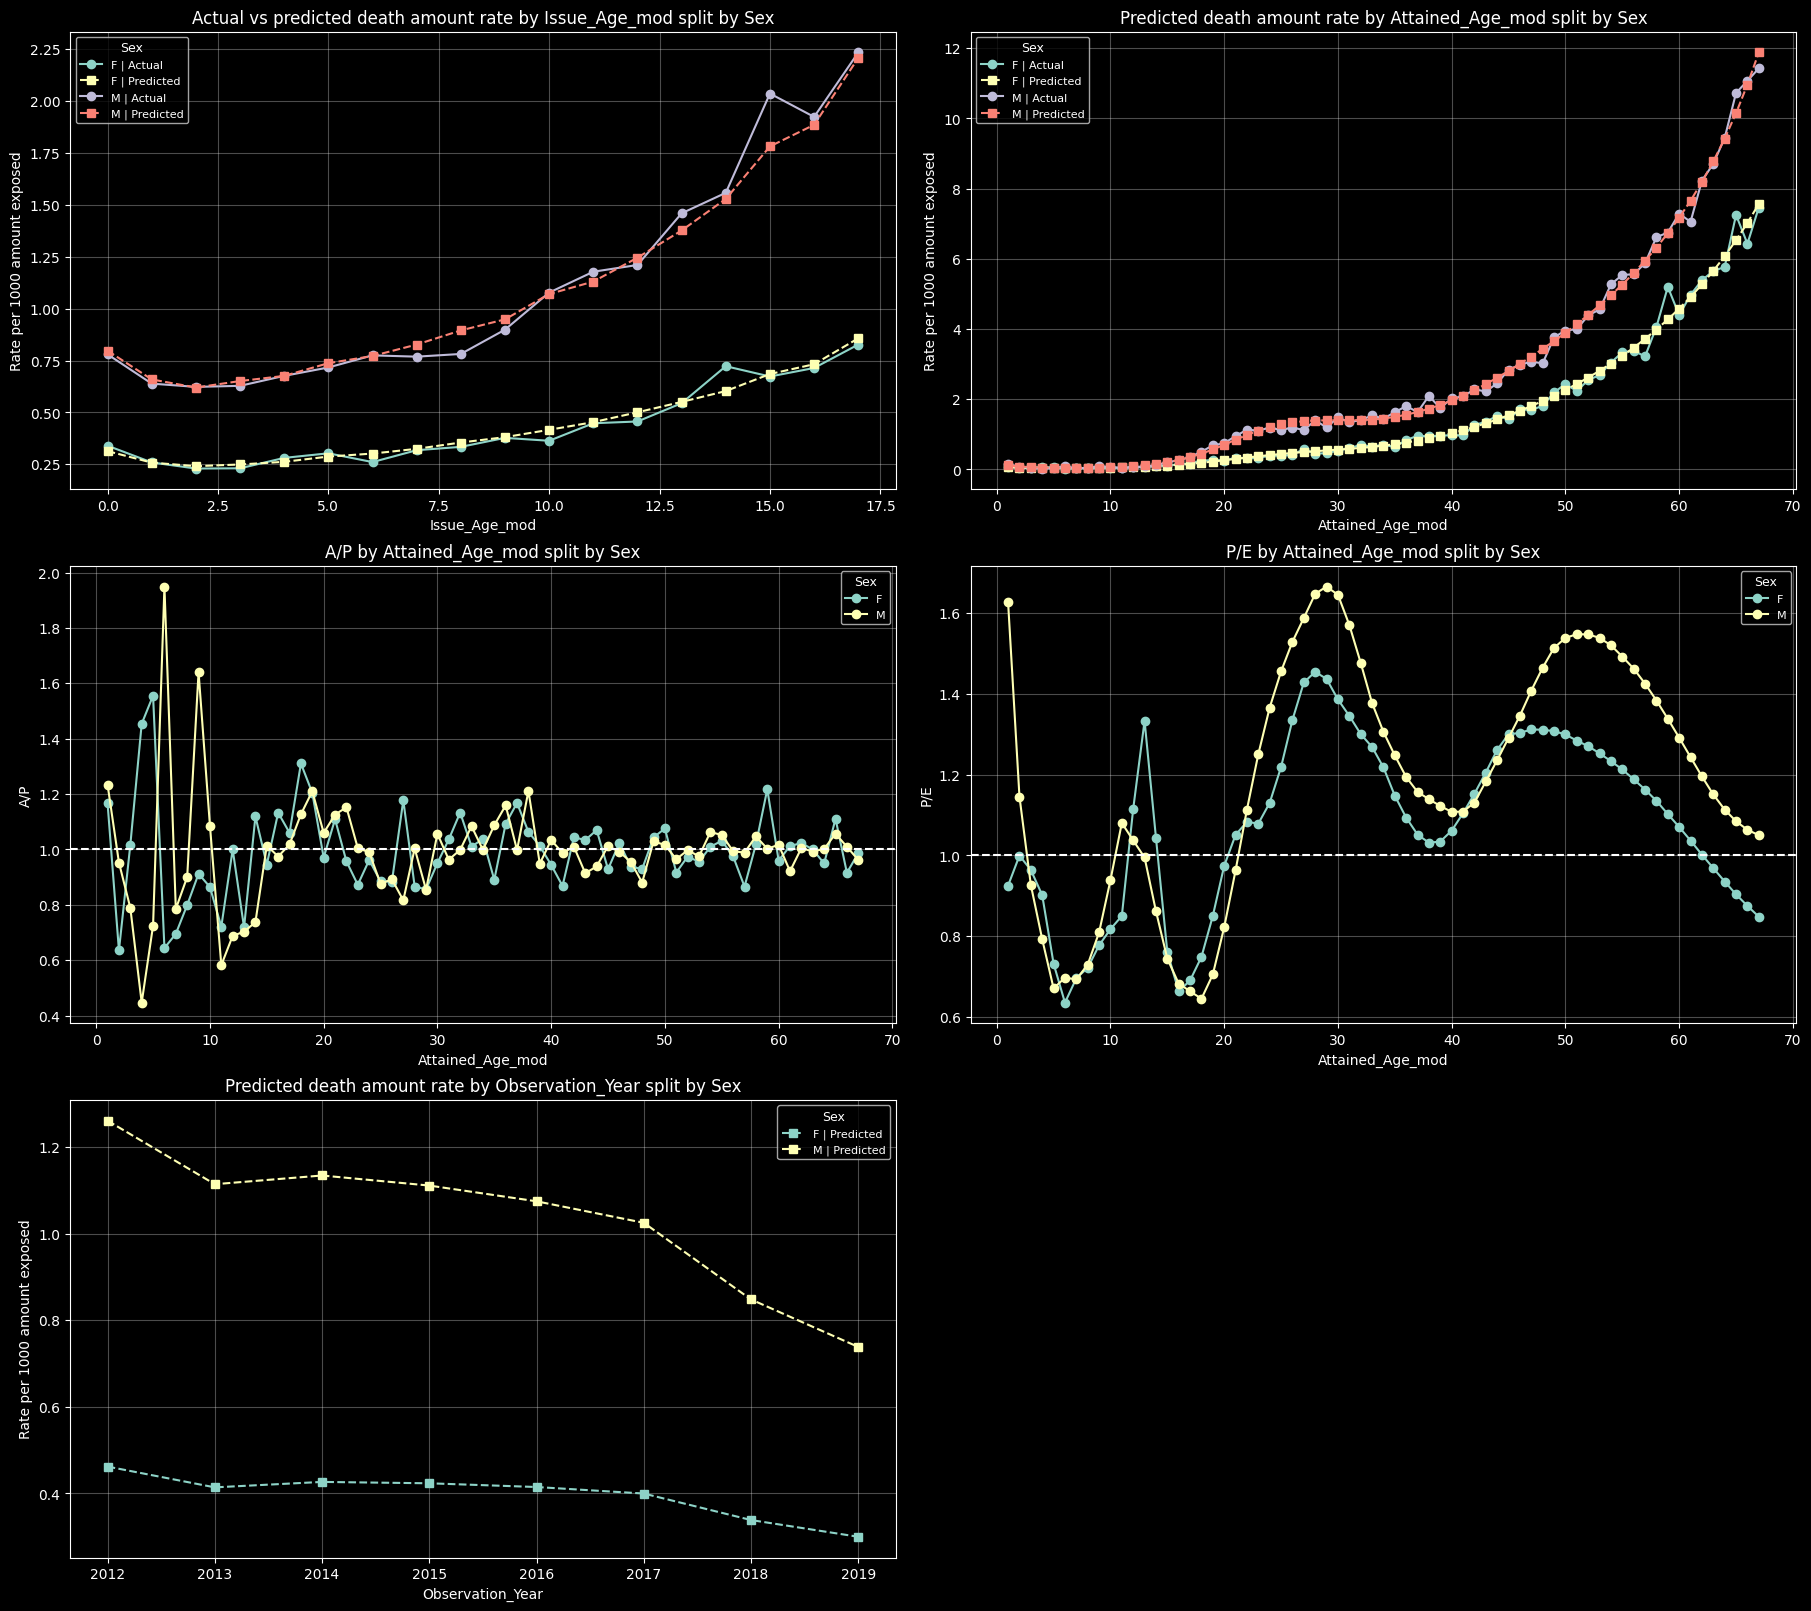

In [14]:
# SESSION 3.4 GRAPH REVIEW

fig, axes = plt.subplots(3, 2, figsize=(18, 16), constrained_layout=True)
axes = axes.ravel()

plot_rate_curves(
    diagnostic_df,
    x_col=ISSUE_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Actual vs predicted death amount rate by Issue_Age_mod split by Sex",
    ax=axes[0],
)

plot_rate_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    rate_col=["Actual_Rate_per_1000", "Predicted_Rate_per_1000"],
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted death amount rate by Attained_Age_mod split by Sex",
    ax=axes[1],
)

plot_ratio_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    numerator_col="Actual_Rate_per_1000",
    denominator_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="A/P by Attained_Age_mod split by Sex",
    y_label="A/P",
    ax=axes[2],
)

plot_ratio_curves(
    diagnostic_df,
    x_col=ATTAINED_AGE_MOD_COL,
    split_col="Sex",
    numerator_col="Predicted_Rate_per_1000",
    denominator_col="Expected_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="P/E by Attained_Age_mod split by Sex",
    y_label="P/E",
    ax=axes[3],
)

plot_rate_curves(
    diagnostic_df,
    x_col="Observation_Year",
    split_col="Sex",
    rate_col="Predicted_Rate_per_1000",
    min_expected=MIN_EXPECTED_FOR_MONOTONICITY,
    title="Predicted death amount rate by Observation_Year split by Sex",
    ax=axes[4],
)

axes[5].set_axis_off()
plt.show()

In [1]:
# SESSION 3.5 APPEND PREDICTED DEATH AMOUNT TO FULL.PARQUET

predicted_death_amount_col = MODEL_PREDICTED_COL
full_parquet_path = DATA_PATH
tmp_parquet_path = full_parquet_path.with_name(
    f"{full_parquet_path.stem}__tmp_with_prediction{full_parquet_path.suffix}"
)

full_parquet_df = read_parquet_data(full_parquet_path)
full_parquet_df = full_parquet_df.drop(columns=[predicted_death_amount_col], errors="ignore")

full_score_df = standardize_frame(full_parquet_df)
full_score_df["Age_Ind"] = (
    full_score_df["Age_Ind"]
    .astype("string")
    .str.upper()
    .map({"ANB": "0", "ALB": "1", "0": "0", "1": "1"})
    .fillna(full_score_df["Age_Ind"].astype("string"))
)
full_score_df["Sex"] = (
    full_score_df["Sex"]
    .astype("string")
    .str.upper()
    .map({"MALE": "M", "FEMALE": "F", "M": "M", "F": "F"})
    .fillna(full_score_df["Sex"].astype("string"))
)
full_score_df = apply_face_amount_cap_1m(full_score_df)
full_score_df = derive_age_basis_columns(full_score_df)
full_score_df = apply_issue_year_exposure_scaling(full_score_df)
full_score_df = add_spline_safe_columns(full_score_df)

score_mask = (
    full_score_df["Sex"].isin(["M", "F"]) &
    pd.to_numeric(full_score_df[MODEL_EXPOSURE_COL], errors="coerce").gt(0) &
    pd.to_numeric(full_score_df[ATTAINED_AGE_MOD_COL], errors="coerce").notna()
).fillna(False)

score_mask_values = score_mask.to_numpy(dtype=bool)
predicted_death_amount = np.full(len(full_parquet_df), np.nan, dtype=np.float32)
score_rows = full_score_df.loc[score_mask].copy()
if len(score_rows) > 0:
    offset = np.log(pd.to_numeric(score_rows[MODEL_EXPOSURE_COL], errors="coerce").clip(1e-10))
    predicted_values = np.clip(
        final_gam_model["result"].predict(score_rows, offset=offset.values),
        1e-12,
        None,
    ).astype(np.float32)
    predicted_death_amount[score_mask_values] = predicted_values

full_parquet_df[predicted_death_amount_col] = predicted_death_amount
original_size_mb = full_parquet_path.stat().st_size / (1024 ** 2)
if tmp_parquet_path.exists():
    tmp_parquet_path.unlink()

if HAS_PYARROW:
    parquet_compression = "zstd" if pyarrow.Codec.is_available("zstd") else "snappy"
    parquet_kwargs = {
        "engine": "pyarrow",
        "index": False,
        "compression": parquet_compression,
    }
    if parquet_compression == "zstd":
        try:
            full_parquet_df.to_parquet(tmp_parquet_path, compression_level=9, **parquet_kwargs)
        except (TypeError, ValueError):
            full_parquet_df.to_parquet(tmp_parquet_path, **parquet_kwargs)
    else:
        full_parquet_df.to_parquet(tmp_parquet_path, **parquet_kwargs)
elif HAS_DUCKDB:
    duckdb.register("_full_parquet_with_prediction", full_parquet_df)
    try:
        try:
            duckdb.sql(
                f"COPY _full_parquet_with_prediction TO '{tmp_parquet_path.as_posix()}' "
                "(FORMAT PARQUET, COMPRESSION ZSTD)"
            )
        except Exception:
            duckdb.sql(
                f"COPY _full_parquet_with_prediction TO '{tmp_parquet_path.as_posix()}' "
                "(FORMAT PARQUET, COMPRESSION SNAPPY)"
            )
    finally:
        duckdb.unregister("_full_parquet_with_prediction")
else:
    raise ImportError(f"Need pyarrow or duckdb to rewrite full.parquet with {predicted_death_amount_col}.")

new_size_mb = tmp_parquet_path.stat().st_size / (1024 ** 2)
tmp_parquet_path.replace(full_parquet_path)
print(
    f"Updated {full_parquet_path} with {predicted_death_amount_col} "
    f"for {int(score_mask_values.sum()):,} of {len(full_parquet_df):,} rows. "
    f"Size: {original_size_mb:.1f} MB -> {new_size_mb:.1f} MB."
)

NameError: name 'MODEL_PREDICTED_COL' is not defined

In [16]:
# SESSION 3.5A ORIGINAL ATTAINED AGE 0 AMOUNT MORTALITIES

ATTAINED_AGE_ZERO_OUTPUT_DURATION_COL = "1"
ATTAINED_AGE_ZERO_RATE_COL = "Original_Attained_Age_0_Amount_Rate_per_1000"


def original_attained_age_zero_scope(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the output scope to original data, keeping attained age 0 for empirical rates."""
    out = standardize_frame(df)
    out["Age_Ind"] = (
        out["Age_Ind"]
        .astype("string")
        .str.upper()
        .map({"ANB": "0", "ALB": "1", "0": "0", "1": "1"})
        .fillna(out["Age_Ind"].astype("string"))
    )
    out["Sex"] = (
        out["Sex"]
        .astype("string")
        .str.upper()
        .map({"MALE": "M", "FEMALE": "F", "M": "M", "F": "F"})
        .fillna(out["Sex"].astype("string"))
    )

    if OBSERVATION_YEARS is not None:
        out = out[out["Observation_Year"].isin(OBSERVATION_YEARS)].copy()

    out = out[out["Issue_Age"].between(ISSUE_AGE_MIN, ISSUE_AGE_MAX, inclusive="both")].copy()

    if ATTAINED_AGE_MAX is not None:
        out = out[out["Attained_Age"] <= ATTAINED_AGE_MAX].copy()

    if AGE_IND_KEEP is not None:
        out = out[out["Age_Ind"].isin(AGE_IND_KEEP)].copy()

    if SEX_KEEP is not None:
        out = out[out["Sex"].isin(SEX_KEEP)].copy()

    if SMOKER_STATUS_KEEP is not None:
        out = out[out["Smoker_Status"].isin(SMOKER_STATUS_KEEP)].copy()

    if INSURANCE_PLAN_DROP:
        out = out[~out["Insurance_Plan"].isin(INSURANCE_PLAN_DROP)].copy()

    if EXCLUDE_POST_LEVEL_TERM:
        out = out[~out["SOA_Post_Lvl_Ind"].isin(POST_LEVEL_TERM_EXCLUDE_VALUES)].copy()

    if COLLAPSE_DURATION_26_PLUS:
        out["Duration"] = np.where(out["Duration"] >= 26, 26, out["Duration"])

    out = apply_face_amount_cap_1m(out)
    out = derive_age_basis_columns(out)
    out = apply_issue_year_exposure_scaling(out)

    age_zero_mask = (
        pd.to_numeric(out["Attained_Age"], errors="coerce").eq(0) &
        pd.to_numeric(out["Issue_Age"], errors="coerce").eq(0) &
        pd.to_numeric(out["Duration"], errors="coerce").eq(1) &
        pd.to_numeric(out[MODEL_EXPOSURE_COL], errors="coerce").gt(0)
    )
    return out[age_zero_mask].copy()


attained_age_zero_source_df = original_attained_age_zero_scope(raw_df)
attained_age_zero_mortalities = (
    attained_age_zero_source_df
    .groupby(["Age_Ind", "Sex"], dropna=False)
    .agg(
        Rows=(MODEL_ACTUAL_COL, "size"),
        Death_Claim_Amount=(MODEL_ACTUAL_COL, "sum"),
        Amount_Exposed=(MODEL_EXPOSURE_COL, "sum"),
    )
    .reset_index()
)
attained_age_zero_mortalities[ATTAINED_AGE_ZERO_RATE_COL] = safe_divide(
    attained_age_zero_mortalities[MODEL_ACTUAL_COL] * OUTPUT_RATE_PER,
    attained_age_zero_mortalities[MODEL_EXPOSURE_COL],
)

attained_age_zero_rate_lookup = {
    (str(row["Age_Ind"]), str(row["Sex"])): row[ATTAINED_AGE_ZERO_RATE_COL]
    for _, row in attained_age_zero_mortalities.iterrows()
    if pd.notna(row[ATTAINED_AGE_ZERO_RATE_COL])
}


def apply_attained_age_zero_original_rates(table: pd.DataFrame, age_ind_value: str, sex_value: str) -> pd.DataFrame:
    out = table.copy()
    mask = out["Iss. Age"].eq(0)
    rate = attained_age_zero_rate_lookup.get((str(age_ind_value), str(sex_value)))
    out.loc[mask, ATTAINED_AGE_ZERO_OUTPUT_DURATION_COL] = rate if pd.notna(rate) else pd.NA
    return out


display(attained_age_zero_mortalities)


,Age_Ind,Sex,Rows,Death_Claim_Amount,Amount_Exposed,Original_Attained_Age_0_Amount_Rate_per_1000
0,0,F,705,1253285,"19,681,007,997.900570",0.063680
1,0,M,715,1633201,"19,727,123,947.838165",0.082790
2,1,F,485,2075034,"12,142,759,475.330486",0.170887
3,1,M,485,2489978,"11,375,628,332.463301",0.218887


In [17]:
# SESSION 3.6 MORTALITY OUTPUTS

sheet_issue_age_min = 0
sheet_issue_age_max = 67
sheet_duration_cols = list(range(1, 26))
rate_cols = [str(d) for d in sheet_duration_cols] + ["Ult."]

age_basis_to_code = {
    "ANB": "0",
    "ALB": "1",
}
sex_to_title = {
    "M": "Male",
    "F": "Female",
}

def predicted_age_basis_grid(age_basis: str, sex_value: str) -> pd.DataFrame:
    """Build original ANB/ALB issue-age and duration rows for model scoring."""
    age_ind_value = age_basis_to_code[age_basis]
    rows = []
    for issue_age in range(sheet_issue_age_min, sheet_issue_age_max + 1):
        for duration in sheet_duration_cols:
            rows.append({
                "Observation_Year": 2015,
                "Age_Ind": age_ind_value,
                "Sex": sex_value,
                "Issue_Age": issue_age,
                "Duration": duration,
                "Attained_Age": issue_age + duration - 1,
                "Slct_Ult_Ind": "S",
                "Policies_Exposed": 1.0,
                "Amount_Exposed": 1.0,
                "Death_Count": 0.0,
                "Death_Claim_Amount": 0.0,
                "ExpDth_VBT2015_Cnt": 1.0,
                "ExpDth_VBT2015_Amt": 1.0,
            })
        rows.append({
            "Observation_Year": 2015,
            "Age_Ind": age_ind_value,
            "Sex": sex_value,
            "Issue_Age": issue_age,
            "Duration": OUTPUT_ULT_DURATION,
            "Attained_Age": issue_age + OUTPUT_SELECT_PERIOD,
            "Slct_Ult_Ind": "U",
            "Policies_Exposed": 1.0,
            "Amount_Exposed": 1.0,
            "Death_Count": 0.0,
            "Death_Claim_Amount": 0.0,
            "ExpDth_VBT2015_Cnt": 1.0,
            "ExpDth_VBT2015_Amt": 1.0,
        })
    return derive_age_basis_columns(standardize_frame(pd.DataFrame(rows)))

def predicted_sheet(age_basis: str, sex_value: str) -> pd.DataFrame:
    scored_grid = score_gam_model(
        final_gam_model,
        predicted_age_basis_grid(age_basis, sex_value),
    )
    table = build_sheet_style_table(
        scored_grid,
        value_col=MODEL_PREDICTED_COL,
        age_ind_value=age_basis_to_code[age_basis],
        sex_value=sex_value,
        select_period=OUTPUT_SELECT_PERIOD,
        ult_duration=OUTPUT_ULT_DURATION,
        duration_cols=sheet_duration_cols,
        rate_per=OUTPUT_RATE_PER,
        issue_age_min=sheet_issue_age_min,
        issue_age_max=sheet_issue_age_max,
    )
    table = apply_attained_age_zero_original_rates(
        table,
        age_ind_value=age_basis_to_code[age_basis],
        sex_value=sex_value,
    )
    return table

predicted_tables = {
    f"Predicted {sex_to_title[sex]} Unismoke {age_basis} Death Amount Rates per 1000 Amount Exposed": predicted_sheet(age_basis, sex)
    for age_basis in ["ANB", "ALB"]
    for sex in ["M", "F"]
}

for title, table in predicted_tables.items():
    print(f"\n{title}")
    with pd.option_context("display.max_rows", sheet_issue_age_max - sheet_issue_age_min + 1, "display.max_columns", None):
        display(table)



Predicted Male Unismoke ANB Death Amount Rates per 1000 Amount Exposed


,Iss. Age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,Ult.,Att. Age
0,0,0.082790,0.116244,0.081273,0.062002,0.051276,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,25.000000
1,1,0.116244,0.081273,0.062002,0.051276,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,26.000000
2,2,0.081273,0.062002,0.051276,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,27.000000
3,3,0.062002,0.051276,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,28.000000
4,4,0.051276,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,29.000000
5,5,0.045670,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,1.398939,30.000000
6,6,0.043526,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,1.398939,1.398715,31.000000
7,7,0.044097,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,1.398939,1.398715,1.403280,32.000000
8,8,0.047184,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,1.398939,1.398715,1.403280,1.418358,33.000000
9,9,0.052975,0.062002,0.075156,0.093739,0.119519,0.154769,0.202223,0.264876,0.345535,0.446008,0.565934,0.701338,0.843329,0.979274,1.100597,1.202015,1.280825,1.336931,1.372488,1.391328,1.398339,1.398939,1.398715,1.403280,1.418358,1.448841,34.000000



Predicted Female Unismoke ANB Death Amount Rates per 1000 Amount Exposed


,Iss. Age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,Ult.,Att. Age
0,0,0.063680,0.064313,0.052529,0.045200,0.040821,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,25.000000
1,1,0.064313,0.052529,0.045200,0.040821,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,26.000000
2,2,0.052529,0.045200,0.040821,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,27.000000
3,3,0.045200,0.040821,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,28.000000
4,4,0.040821,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,29.000000
5,5,0.038545,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,0.562283,30.000000
6,6,0.037910,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,0.562283,0.585664,31.000000
7,7,0.038690,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,0.562283,0.585664,0.611334,32.000000
8,8,0.040817,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,0.562283,0.585664,0.611334,0.640920,33.000000
9,9,0.044346,0.049428,0.056306,0.065307,0.076831,0.091334,0.109297,0.131163,0.157252,0.187636,0.221985,0.259401,0.298273,0.336539,0.373046,0.407149,0.438499,0.467052,0.493063,0.517060,0.539807,0.562283,0.585664,0.611334,0.640920,0.676044,34.000000



Predicted Male Unismoke ALB Death Amount Rates per 1000 Amount Exposed


,Iss. Age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,Ult.,Att. Age
0,0,0.218887,0.096105,0.070245,0.055841,0.047965,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,25.500000
1,1,0.096105,0.070245,0.055841,0.047965,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,26.500000
2,2,0.070245,0.055841,0.047965,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,27.500000
3,3,0.055841,0.047965,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,28.500000
4,4,0.047965,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,29.500000
5,5,0.044228,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,1.398580,30.500000
6,6,0.043495,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,1.398580,1.400046,31.500000
7,7,0.045323,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,1.398580,1.400046,1.409136,32.500000
8,8,0.049716,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,1.398580,1.400046,1.409136,1.431573,33.500000
9,9,0.057037,0.067992,0.083670,0.105599,0.135799,0.176785,0.231462,0.302806,0.393250,0.503686,0.632129,0.772282,0.912709,1.042151,1.154026,1.244310,1.311628,1.357071,1.383710,1.395981,1.399093,1.398580,1.400046,1.409136,1.431573,1.470093,34.500000



Predicted Female Unismoke ALB Death Amount Rates per 1000 Amount Exposed


,Iss. Age,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,Ult.,Att. Age
0,0,0.170887,0.057732,0.048422,0.042706,0.039455,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,25.500000
1,1,0.057732,0.048422,0.042706,0.039455,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,26.500000
2,2,0.048422,0.042706,0.039455,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,27.500000
3,3,0.042706,0.039455,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,28.500000
4,4,0.039455,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,29.500000
5,5,0.038041,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,0.573779,30.500000
6,6,0.038130,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,0.573779,0.598117,31.500000
7,7,0.039584,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,0.573779,0.598117,0.625524,32.500000
8,8,0.042399,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,0.573779,0.598117,0.625524,0.657735,33.500000
9,9,0.046679,0.052624,0.060518,0.070726,0.083680,0.099854,0.119718,0.143667,0.171916,0.204356,0.240392,0.278786,0.317575,0.355059,0.390427,0.423178,0.453115,0.480348,0.505271,0.528533,0.551010,0.573779,0.598117,0.625524,0.657735,0.695886,34.500000
